In [1]:
import torch
import pandas as pd
import copy

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

from model import*

In [2]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=256)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [5]:
from model import SimpleMLP, train, evaluate, test
from ElasticOptim import ElasticOptim

# ── Data ───────────────────────────────────────────────────────────────────
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(root="./data", train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=256)

device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion = nn.CrossEntropyLoss()

# ── Fix batches for fair comparison ────────────────────────────────────────
all_batches = list(train_loader)

# ── Config ─────────────────────────────────────────────────────────────────
n_epochs  = 10
n_workers = 3
lr        = 0.1

results_df = pd.DataFrame(columns=[
    "Optimizer", "Train Loss", "Test Loss",
    "learning_rate", "Test Accuracy",
    "train_loss_curve", "test_loss_curve"
])

# ── SGD baseline ───────────────────────────────────────────────────────────
print("── SGD baseline ──")
model     = SimpleMLP().to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=lr)

train_loss_curve, test_loss_curve = [], []

for epoch in range(n_epochs):
    model.train()
    for x, y in all_batches:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        criterion(model(x), y).backward()
        optimizer.step()

    tr_loss = evaluate(model, train_loader, criterion, device)
    te_loss = evaluate(model, test_loader,  criterion, device)
    train_loss_curve.append(tr_loss)
    test_loss_curve.append(te_loss)

    if (epoch + 1) % 5 == 0:
        print(f"  epoch {epoch+1}/{n_epochs}  train={tr_loss:.4f}  test={te_loss:.4f}")

accuracy = test(model, test_loader, device)
print(f"  accuracy: {accuracy:.4f}")
results_df.loc[len(results_df)] = [
    "SGD", tr_loss, te_loss, lr, accuracy, train_loss_curve, test_loss_curve
]

# ── ElasticOptim ───────────────────────────────────────────────────────────
print("\n── ElasticOptim ──")
workers   = [SimpleMLP().to(device) for _ in range(n_workers)]
master    = SimpleMLP().to(device)
worker_optims = [torch.optim.SGD(m.parameters(), lr=lr) for m in workers]

elastic_opt = ElasticOptim(
    workers=workers,
    master=master,
    optimizers=worker_optims,
    val_loader=test_loader,
    alpha=0.1, beta=5.0, tau=10,
    device=device
)

train_loss_curve, test_loss_curve = [], []

for epoch in range(n_epochs):
    for i in range(0, len(all_batches) - n_workers, n_workers):
        batches = all_batches[i : i + n_workers]
        elastic_opt.step(batches)

    tr_loss = evaluate(master, train_loader, criterion, device)
    te_loss = evaluate(master, test_loader,  criterion, device)
    train_loss_curve.append(tr_loss)
    test_loss_curve.append(te_loss)

    if (epoch + 1) % 5 == 0:
        print(f"  epoch {epoch+1}/{n_epochs}  train={tr_loss:.4f}  test={te_loss:.4f}")

accuracy = test(master, test_loader, device)
print(f"  accuracy: {accuracy:.4f}")
results_df.loc[len(results_df)] = [
    "ElasticOptim", tr_loss, te_loss, lr, accuracy, train_loss_curve, test_loss_curve
]

print("\n── Results ──")
print(results_df[["Optimizer", "learning_rate", "Train Loss", "Test Loss", "Test Accuracy"]])

── SGD baseline ──
  epoch 5/10  train=0.1661  test=0.1707
  epoch 10/10  train=0.1009  test=0.1182
  accuracy: 0.9665

── ElasticOptim ──
  epoch 5/10  train=0.3596  test=0.3449
  epoch 10/10  train=0.2586  test=0.2514
  accuracy: 0.9292

── Results ──
      Optimizer  learning_rate  Train Loss  Test Loss  Test Accuracy
0           SGD            0.1    0.100875   0.118165         0.9665
1  ElasticOptim            0.1    0.258595   0.251411         0.9292


In [3]:
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD

results_MNIST_df = pd.DataFrame(columns=["Optimizer", "Train Loss", "Test Loss", "learning_rate", "Test Accuracy", "train_loss_curve", "test_loss_curve"])

lrs = [0.01]#, 0.05, 0.1, 0.5]
n_epochs = 10
# track loss (test and train) for each epoch, for each optimizer, for each lr

for lr in lrs:
    print(f"Running with learning rate: {lr}")
    base_model = SimpleMLP().to(device)
    optimizer_sgd = torch.optim.SGD(base_model.parameters(), lr=lr)
    
    train_loss_curve_sgd = []
    test_loss_curve_sgd = []
    # --- training ---
    for epoch in range(n_epochs):
        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1}/{n_epochs}")
        train_loss_sgd = train(base_model, optimizer_sgd, train_loader, criterion)

        train_loss_curve_sgd.append(train_loss_sgd)

        # --- evaluation ---
        test_loss_sgd = evaluate(base_model, test_loader, criterion)
        test_loss_curve_sgd.append(test_loss_sgd)

    accuracy_sgd = test(base_model, test_loader)

    # --- logging ---
    results_MNIST_df.loc[len(results_MNIST_df)] = [ "SGD", train_loss_sgd, test_loss_sgd, lr, accuracy_sgd, train_loss_curve_sgd, test_loss_curve_sgd]

Running with learning rate: 0.01


TypeError: train() missing 1 required positional argument: 'device'

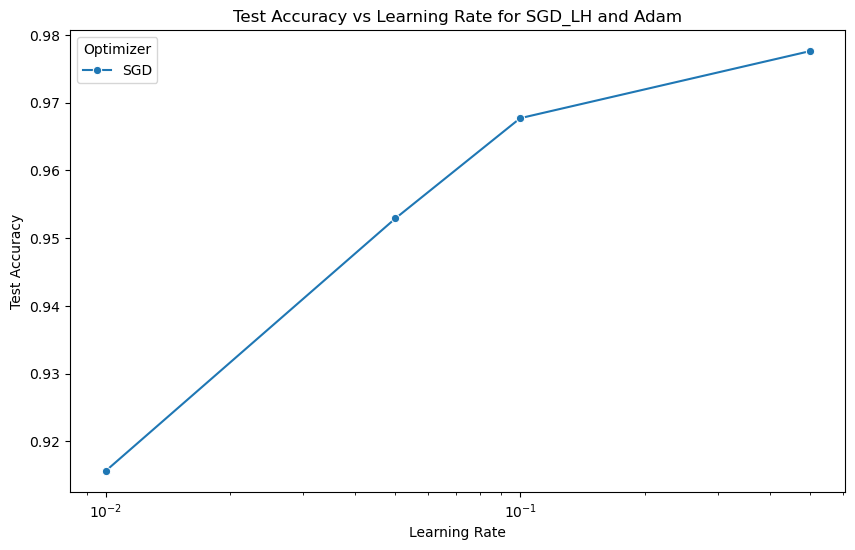

In [ ]:
# plot test accuracy vs learning rate for both optimizers
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
sns.lineplot(data=results_MNIST_df, x="learning_rate", y="Test Accuracy", hue="Optimizer", marker="o")
plt.title("Test Accuracy vs Learning Rate for SGD_LH and Adam")
plt.ylabel("Test Accuracy")
plt.xlabel("Learning Rate")
plt.xscale("log")
plt.legend(title="Optimizer")
plt.show()